# SANAD — Stage 2, Experiment B
## Dense Retrieval vs BM25 vs Hybrid Retrieval (RRF)

This notebook reproduces Experiment B in a transparent way.

**Primary comparison**
- Dense Retrieval: BGE-M3 + FAISS
- Hybrid Retrieval: Dense + BM25 fused with Reciprocal Rank Fusion (RRF)

**Diagnostic baseline**
- BM25-only is also reported.

**Fairness conditions**
- Same 4,226 clean legal records
- Same 60 gold queries
- Same gold law/article labels
- Same document representation: `law_name + article_number + text`
- Same Recall@3, Recall@5, and MRR calculations

Use the corrected `bge_m3_saudi_legal.index` built from the shared document representation.


## 1. Install libraries

In [1]:
!pip install -q faiss-cpu rank-bm25 sentence-transformers transformers accelerate pyarrow openpyxl

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 18.8/18.8 MB 46.5 MB/s eta 0:00:00


## 2. Upload required files

In [3]:
from google.colab import files
import os

print("Upload:")
print("1) saudi_legal_moj_clean.parquet")
print("2) SANAD_Retrieval_Test_Set_60.xlsx")
print("3) bge_m3_saudi_legal.index")

uploaded = files.upload()
print(os.listdir("/content"))


Upload:
1) saudi_legal_moj_clean.parquet
2) SANAD_Retrieval_Test_Set_60.xlsx
3) bge_m3_saudi_legal.index


Saving bge_m3_saudi_legal.index to bge_m3_saudi_legal.index
Saving SANAD_Retrieval_Test_Set_60.xlsx to SANAD_Retrieval_Test_Set_60.xlsx
Saving saudi_legal_moj_clean.parquet to saudi_legal_moj_clean.parquet
['.config', 'SANAD_Retrieval_Test_Set_60.xlsx', 'bge_m3_saudi_legal.index', 'saudi_legal_moj_clean.parquet', 'sample_data']


## 3. Load and verify files

In [4]:
import pandas as pd
import numpy as np
import faiss

DATA_PATH = "/content/saudi_legal_moj_clean.parquet"
TEST_PATH = "/content/SANAD_Retrieval_Test_Set_60.xlsx"
INDEX_PATH = "/content/bge_m3_saudi_legal.index"

df = pd.read_parquet(DATA_PATH).reset_index(drop=True)
test_df = pd.read_excel(TEST_PATH, sheet_name="Test_Set")
bge_index = faiss.read_index(INDEX_PATH)

print("Dataset rows:", len(df))
print("Test queries:", len(test_df))
print("Indexed vectors:", bge_index.ntotal)
print("Vector dimension:", bge_index.d)

assert len(df) == bge_index.ntotal
assert len(test_df) == 60

print("Verification passed ✅")


Dataset rows: 4226
Test queries: 60
Indexed vectors: 4226
Vector dimension: 1024
Verification passed ✅


## 4. Shared document representation

In [5]:
def build_document_text(row):
    return (
        "اسم النظام: " + str(row["law_name"]) +
        "\nرقم المادة: " + str(row["article_number"]) +
        "\nالنص القانوني: " + str(row["text"])
    )

documents = [build_document_text(row) for _, row in df.iterrows()]

print("Documents:", len(documents))
print(documents[0][:600])


Documents: 4226
اسم النظام: نظام مكافحة جرائم الإرهاب وتمويله
رقم المادة: المادة الأولى
النص القانوني: المادة الأولى
يقصد بالألفاظ والعبارات الآتية -أينما وردت في هذا النظام- المعاني الموضحة أمام كل منهاء ما لم يقتض السياق خلافذلك:
-١ النظام: نظام مكافحة جرائم الإرهابوتمويله.
-١ اللائحة: اللائحة التنفيذيةللنظام.
؟- الجريمة الإرهابية: كل سلوك يقوم به الجاني تنفيذاً لمشروع إجرامي فردي أو جماعي بشكل مباشر أو غير مباشرء يقصد به الإخلال بالنظام العام» أو زعزعة أمنالمجتمع
واستقرار الدولة أو تعريض وحدتها الوطنية للخطرء أو تعطيل النظام الأساسي للحكم أو بعض أحكامه؛ أو إلحاق الضرر بأحد مرافق الدولة أو مواردها الطبيعية 


## 5. Arabic normalization and BM25 tokenization

In [6]:
import re

def normalize_arabic(text):
    text = str(text)

    # Remove Arabic diacritics and tatweel
    text = re.sub(r"[\u064B-\u065F\u0670\u0640]", "", text)

    # Normalize common letter variants
    text = re.sub(r"[إأآٱ]", "ا", text)
    text = text.replace("ى", "ي")
    text = text.replace("ؤ", "و")
    text = text.replace("ئ", "ي")

    # Keep Arabic/Latin letters, digits, and spaces
    text = re.sub(r"[^\u0600-\u06FFa-zA-Z0-9\s]", " ", text)
    text = re.sub(r"\s+", " ", text).strip()

    return text

def tokenize_arabic(text):
    return normalize_arabic(text).split()

tokenized_documents = [tokenize_arabic(doc) for doc in documents]

print(tokenized_documents[0][:40])


['اسم', 'النظام', 'نظام', 'مكافحة', 'جرايم', 'الارهاب', 'وتمويله', 'رقم', 'المادة', 'المادة', 'الاولي', 'النص', 'القانوني', 'المادة', 'الاولي', 'يقصد', 'بالالفاظ', 'والعبارات', 'الاتية', 'اينما', 'وردت', 'في', 'هذا', 'النظام', 'المعاني', 'الموضحة', 'امام', 'كل', 'منهاء', 'ما', 'لم', 'يقتض', 'السياق', 'خلافذلك', '١', 'النظام', 'نظام', 'مكافحة', 'جرايم', 'الارهابوتمويله']


## 6. Build BM25

In [7]:
from rank_bm25 import BM25Okapi

BM25_K1 = 1.5
BM25_B = 0.75

bm25 = BM25Okapi(
    tokenized_documents,
    k1=BM25_K1,
    b=BM25_B
)

print("BM25 built ✅")
print("k1 =", BM25_K1)
print("b  =", BM25_B)


BM25 built ✅
k1 = 1.5
b  = 0.75


## 7. Load BGE-M3 for query embeddings

In [8]:
import torch
from sentence_transformers import SentenceTransformer

device = "cuda" if torch.cuda.is_available() else "cpu"

bge_model = SentenceTransformer(
    "BAAI/bge-m3",
    device=device
)
bge_model.max_seq_length = 2048

print("Device:", device)
print("BGE-M3 loaded ✅")


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/123 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/15.8k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/54.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/687 [00:00<?, ?B/s]

...

tokenizer.json: reconstructing file:   0%|          |  0.00B / 17.1MB            

tokenizer.json: downloading bytes:           |  0.00B            

special_tokens_map.json:   0%|          | 0.00/964 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/191 [00:00<?, ?B/s]

Device: cpu
BGE-M3 loaded ✅


## 8. Retrieval functions

Hybrid uses Reciprocal Rank Fusion:

`RRF(d) = 1 / (k + rank_dense) + 1 / (k + rank_bm25)`

with `k = 60`.


In [9]:
RRF_K = 60

def dense_ranking(query):
    q_emb = bge_model.encode(
        [str(query)],
        normalize_embeddings=True
    )
    q_emb = np.asarray(q_emb, dtype="float32")

    scores, indices = bge_index.search(
        q_emb,
        bge_index.ntotal
    )
    return indices[0].astype(int), scores[0]


def bm25_ranking(query):
    tokens = tokenize_arabic(query)
    raw_scores = np.asarray(bm25.get_scores(tokens), dtype=np.float64)

    indices = np.argsort(-raw_scores, kind="stable")
    ranked_scores = raw_scores[indices]

    return indices.astype(int), ranked_scores


def reciprocal_rank_fusion(dense_indices, bm25_indices, k=60):
    n = len(df)

    dense_rank = np.empty(n, dtype=np.int32)
    bm25_rank = np.empty(n, dtype=np.int32)

    dense_rank[dense_indices] = np.arange(1, n + 1)
    bm25_rank[bm25_indices] = np.arange(1, n + 1)

    rrf_scores = (
        1.0 / (k + dense_rank) +
        1.0 / (k + bm25_rank)
    )

    hybrid_indices = np.argsort(-rrf_scores, kind="stable")
    hybrid_scores = rrf_scores[hybrid_indices]

    return hybrid_indices.astype(int), hybrid_scores


def get_gold_rank(ranking_indices, gold_law, gold_article):
    gold_law = str(gold_law).strip()
    gold_article = str(gold_article).strip()

    for rank, idx in enumerate(ranking_indices, start=1):
        row = df.iloc[int(idx)]

        if (
            str(row["law_name"]).strip() == gold_law
            and str(row["article_number"]).strip() == gold_article
        ):
            return rank

    return None


def metric_values(gold_rank):
    return {
        "Recall@3": int(gold_rank is not None and gold_rank <= 3),
        "Recall@5": int(gold_rank is not None and gold_rank <= 5),
        "RR": 0 if gold_rank is None else 1 / gold_rank,
    }


## 9. Warm-up

In [10]:
_ = bge_model.encode(
    ["ما حقوق العامل؟"],
    normalize_embeddings=True
)

print("Warm-up completed ✅")


Warm-up completed ✅


## 10. Evaluate all 60 queries

In [11]:
import time
from tqdm.auto import tqdm

rows = []

for _, test_row in tqdm(
    test_df.iterrows(),
    total=len(test_df),
    desc="Experiment B"
):
    query_id = test_row["query_id"]
    query_type = test_row["query_type"]
    query = str(test_row["query"])
    gold_law = str(test_row["gold_law"]).strip()
    gold_article = str(test_row["gold_article"]).strip()

    # Dense
    start = time.perf_counter()
    dense_indices, dense_scores = dense_ranking(query)
    dense_time = time.perf_counter() - start

    # BM25
    start = time.perf_counter()
    bm25_indices, bm25_scores = bm25_ranking(query)
    bm25_time = time.perf_counter() - start

    # Hybrid fusion
    start = time.perf_counter()
    hybrid_indices, hybrid_scores = reciprocal_rank_fusion(
        dense_indices,
        bm25_indices,
        k=RRF_K
    )
    fusion_time = time.perf_counter() - start
    hybrid_time = dense_time + bm25_time + fusion_time

    dense_rank = get_gold_rank(dense_indices, gold_law, gold_article)
    bm25_rank = get_gold_rank(bm25_indices, gold_law, gold_article)
    hybrid_rank = get_gold_rank(hybrid_indices, gold_law, gold_article)

    dense_m = metric_values(dense_rank)
    bm25_m = metric_values(bm25_rank)
    hybrid_m = metric_values(hybrid_rank)

    result = {
        "query_id": query_id,
        "query_type": query_type,
        "query": query,
        "gold_law": gold_law,
        "gold_article": gold_article,

        "Dense_Gold_Rank": dense_rank,
        "Dense_Recall@3": dense_m["Recall@3"],
        "Dense_Recall@5": dense_m["Recall@5"],
        "Dense_RR": dense_m["RR"],
        "Dense_Time_s": dense_time,

        "BM25_Gold_Rank": bm25_rank,
        "BM25_Recall@3": bm25_m["Recall@3"],
        "BM25_Recall@5": bm25_m["Recall@5"],
        "BM25_RR": bm25_m["RR"],
        "BM25_Time_s": bm25_time,

        "Hybrid_Gold_Rank": hybrid_rank,
        "Hybrid_Recall@3": hybrid_m["Recall@3"],
        "Hybrid_Recall@5": hybrid_m["Recall@5"],
        "Hybrid_RR": hybrid_m["RR"],
        "Hybrid_Time_s": hybrid_time,
    }

    # Top-5 details
    for method, indices, scores in [
        ("Dense", dense_indices, dense_scores),
        ("BM25", bm25_indices, bm25_scores),
        ("Hybrid", hybrid_indices, hybrid_scores),
    ]:
        for r in range(5):
            idx = int(indices[r])
            row = df.iloc[idx]

            result[f"{method}_Top{r+1}_Law"] = str(row["law_name"])
            result[f"{method}_Top{r+1}_Article"] = str(row["article_number"])
            result[f"{method}_Top{r+1}_Score"] = float(scores[r])

    rows.append(result)

results_df = pd.DataFrame(rows)

print("Finished ✅")
print("Queries evaluated:", len(results_df))
display(results_df.head())


Experiment B:   0%|          | 0/60 [00:00<?, ?it/s]

Finished ✅
Queries evaluated: 60


,query_id,query_type,query,gold_law,gold_article,Dense_Gold_Rank,Dense_Recall@3,Dense_Recall@5,Dense_RR,Dense_Time_s,...,Hybrid_Top2_Score,Hybrid_Top3_Law,Hybrid_Top3_Article,Hybrid_Top3_Score,Hybrid_Top4_Law,Hybrid_Top4_Article,Hybrid_Top4_Score,Hybrid_Top5_Law,Hybrid_Top5_Article,Hybrid_Top5_Score
0,Q001,formal_direct,ما الدعاوى والطلبات التي لا تسري عليها أحكام ا...,نظام التكاليف القضائية,المادة الثانية,3.0,1,1,0.333333,0.690376,...,0.031545,اللائحة التنفيذية لنظام التكاليف القضائية,المادة الثالثة,0.030579,اللائحة التنفيذية لنظام المحاكم التجارية,المادة الحادية والخمسون,0.030310,نظام التكاليف القضائية,المادة الثامنة,0.029139
1,Q002,formal_paraphrase,ما الحالات المستثناة من تطبيق نظام التكاليف ال...,نظام التكاليف القضائية,المادة الثانية,5.0,0,1,0.200000,0.517942,...,0.029572,اللائحة التنفيذية لنظام التكاليف القضائية,المادة الخامسة,0.028485,نظام التكاليف القضائية,المادة الأولى,0.028439,نظام التكاليف القضائية,المادة السابعةعشرة,0.027757
2,Q003,informal,وش القضايا اللي ما عليها تكاليف قضائية؟,نظام التكاليف القضائية,المادة الثانية,9.0,0,0,0.111111,0.509197,...,0.030478,نظام التكاليف القضائية,المادة الثالثة,0.029139,نظام التكاليف القضائية,المادة العاشرة,0.028177,نظام التكاليف القضائية,المادة السادسة,0.027056
3,Q004,formal_direct,ما الحد الأعلى للتكاليف القضائية المفروضة على ...,نظام التكاليف القضائية,المادة الثالثة,1.0,1,1,1.000000,0.565970,...,0.029462,نظام التكاليف القضائية,المادة الثالثة,0.029380,نظام التكاليف القضائية,المادة الثالثةعشرة,0.028814,اللائحة التنفيذية لنظام التكاليف القضائية,المادة الخامسة,0.028595
4,Q005,formal_paraphrase,كيف يتم تحديد قيمة التكاليف القضائية بالنسبة إ...,نظام التكاليف القضائية,المادة الثالثة,2.0,1,1,0.500000,0.539166,...,0.031754,اللائحة التنفيذية لنظام التكاليف القضائية,المادة الخامسة,0.031514,نظام التكاليف القضائية,المادة التاسعة,0.031319,نظام التكاليف القضائية,المادة الثالثةعشرة,0.029274


## 11. Overall results

In [12]:
def summarize_method(method):
    return {
        "Method": method,
        "Recall@3": results_df[f"{method}_Recall@3"].mean(),
        "Recall@5": results_df[f"{method}_Recall@5"].mean(),
        "MRR": results_df[f"{method}_RR"].mean(),
        "Avg_Time_s": results_df[f"{method}_Time_s"].mean(),
    }

overall_df = pd.DataFrame([
    summarize_method("Dense"),
    summarize_method("BM25"),
    summarize_method("Hybrid"),
])

display(overall_df)


,Method,Recall@3,Recall@5,MRR,Avg_Time_s
0,Dense,0.783333,0.850000,0.708426,0.435391
1,BM25,0.450000,0.516667,0.416150,0.015368
2,Hybrid,0.666667,0.700000,0.572895,0.451277


## 12. Primary comparison: Dense vs Hybrid

In [13]:
dense = overall_df[overall_df["Method"] == "Dense"].iloc[0]
hybrid = overall_df[overall_df["Method"] == "Hybrid"].iloc[0]

comparison_df = pd.DataFrame({
    "Metric": ["Recall@3", "Recall@5", "MRR", "Avg_Time_s"],
    "Dense": [
        dense["Recall@3"],
        dense["Recall@5"],
        dense["MRR"],
        dense["Avg_Time_s"],
    ],
    "Hybrid": [
        hybrid["Recall@3"],
        hybrid["Recall@5"],
        hybrid["MRR"],
        hybrid["Avg_Time_s"],
    ],
})

comparison_df["Hybrid_minus_Dense"] = (
    comparison_df["Hybrid"] - comparison_df["Dense"]
)

display(comparison_df)


,Metric,Dense,Hybrid,Hybrid_minus_Dense
0,Recall@3,0.783333,0.666667,-0.116667
1,Recall@5,0.850000,0.700000,-0.150000
2,MRR,0.708426,0.572895,-0.135531
3,Avg_Time_s,0.435391,0.451277,0.015885


## 13. Results by query type

In [14]:
type_rows = []

for query_type, group in results_df.groupby("query_type"):
    for method in ["Dense", "BM25", "Hybrid"]:
        type_rows.append({
            "query_type": query_type,
            "Method": method,
            "Recall@3": group[f"{method}_Recall@3"].mean(),
            "Recall@5": group[f"{method}_Recall@5"].mean(),
            "MRR": group[f"{method}_RR"].mean(),
            "Avg_Time_s": group[f"{method}_Time_s"].mean(),
        })

by_type_df = pd.DataFrame(type_rows)
display(by_type_df)


,query_type,Method,Recall@3,Recall@5,MRR,Avg_Time_s
0,formal_direct,Dense,0.90,0.90,0.791667,0.444210
1,formal_direct,BM25,0.70,0.80,0.667130,0.016496
2,formal_direct,Hybrid,0.85,0.85,0.735057,0.461217
3,formal_paraphrase,Dense,0.75,0.85,0.653056,0.435825
4,formal_paraphrase,BM25,0.45,0.55,0.393824,0.015592
5,formal_paraphrase,Hybrid,0.70,0.70,0.547936,0.451954
6,informal,Dense,0.70,0.80,0.680556,0.426140
7,informal,BM25,0.20,0.20,0.187495,0.014015
8,informal,Hybrid,0.45,0.55,0.435693,0.440659


## 14. Hybrid win / tie / loss by gold rank

In [15]:
def safe_rank(x):
    return 10**9 if pd.isna(x) else int(x)

wins = 0
ties = 0
losses = 0

for _, row in results_df.iterrows():
    d = safe_rank(row["Dense_Gold_Rank"])
    h = safe_rank(row["Hybrid_Gold_Rank"])

    if h < d:
        wins += 1
    elif h == d:
        ties += 1
    else:
        losses += 1

win_tie_loss_df = pd.DataFrame([{
    "Hybrid better rank": wins,
    "Same rank": ties,
    "Hybrid worse rank": losses,
}])

display(win_tie_loss_df)


,Hybrid better rank,Same rank,Hybrid worse rank
0,9,30,21


## 15. Paired bootstrap 95% confidence intervals

In [16]:
rng = np.random.default_rng(42)
N_BOOT = 5000

def paired_bootstrap_diff(dense_values, hybrid_values):
    dense_values = np.asarray(dense_values, dtype=float)
    hybrid_values = np.asarray(hybrid_values, dtype=float)

    n = len(dense_values)
    observed = hybrid_values.mean() - dense_values.mean()
    diffs = np.empty(N_BOOT)

    for i in range(N_BOOT):
        idx = rng.integers(0, n, size=n)
        diffs[i] = (
            hybrid_values[idx].mean()
            - dense_values[idx].mean()
        )

    lo, hi = np.percentile(diffs, [2.5, 97.5])
    return observed, lo, hi

ci_rows = []

for metric, d_col, h_col in [
    ("Recall@3", "Dense_Recall@3", "Hybrid_Recall@3"),
    ("Recall@5", "Dense_Recall@5", "Hybrid_Recall@5"),
    ("MRR", "Dense_RR", "Hybrid_RR"),
]:
    diff, lo, hi = paired_bootstrap_diff(
        results_df[d_col],
        results_df[h_col]
    )

    ci_rows.append({
        "Metric": metric,
        "Hybrid-Dense": diff,
        "95% CI Lower": lo,
        "95% CI Upper": hi,
    })

ci_df = pd.DataFrame(ci_rows)
display(ci_df)

print(
    "If the 95% CI crosses 0, the improvement is not clearly "
    "separated from no change on this 60-query test set."
)


,Metric,Hybrid-Dense,95% CI Lower,95% CI Upper
0,Recall@3,-0.116667,-0.233333,0.000000
1,Recall@5,-0.150000,-0.266667,-0.033333
2,MRR,-0.135531,-0.249804,-0.028380


If the 95% CI crosses 0, the improvement is not clearly separated from no change on this 60-query test set.


## 16. Chart

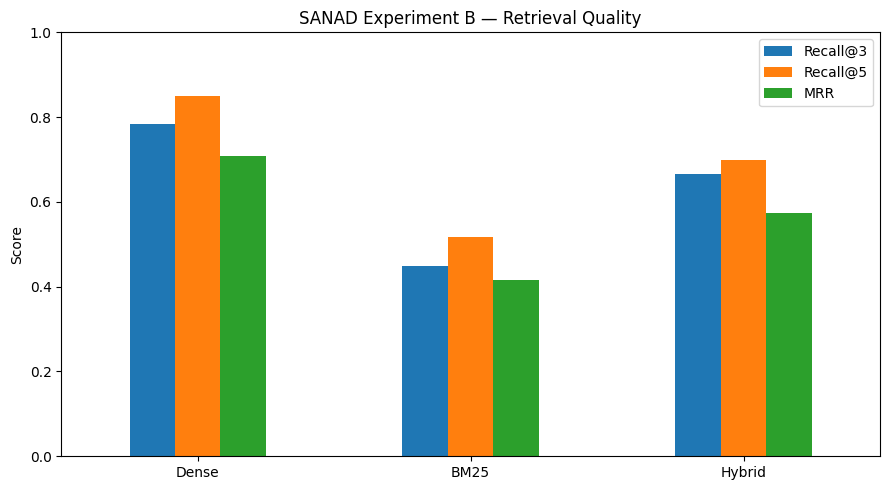

In [17]:
import matplotlib.pyplot as plt

quality = overall_df.set_index("Method")[["Recall@3", "Recall@5", "MRR"]]

ax = quality.plot(kind="bar", figsize=(9, 5))
ax.set_title("SANAD Experiment B — Retrieval Quality")
ax.set_ylabel("Score")
ax.set_xlabel("")
ax.set_ylim(0, 1)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()


## 17. Save results

In [18]:
OUTPUT_XLSX = "/content/SANAD_Experiment_B_Retrieval_Comparison.xlsx"
OUTPUT_CSV = "/content/SANAD_Experiment_B_Per_Query.csv"

results_df.to_csv(
    OUTPUT_CSV,
    index=False,
    encoding="utf-8-sig"
)

with pd.ExcelWriter(OUTPUT_XLSX, engine="openpyxl") as writer:
    overall_df.to_excel(writer, sheet_name="Overall", index=False)
    comparison_df.to_excel(writer, sheet_name="Dense_vs_Hybrid", index=False)
    by_type_df.to_excel(writer, sheet_name="By_Query_Type", index=False)
    win_tie_loss_df.to_excel(writer, sheet_name="Win_Tie_Loss", index=False)
    ci_df.to_excel(writer, sheet_name="Bootstrap_CI", index=False)
    results_df.to_excel(writer, sheet_name="Per_Query", index=False)

print("Saved ✅")
print(OUTPUT_XLSX)
print(OUTPUT_CSV)


Saved ✅
/content/SANAD_Experiment_B_Retrieval_Comparison.xlsx
/content/SANAD_Experiment_B_Per_Query.csv


## 18. Download results

In [ ]:
from google.colab import files

files.download("/content/SANAD_Experiment_B_Retrieval_Comparison.xlsx")
files.download("/content/SANAD_Experiment_B_Per_Query.csv")


# Interpretation

Use the actual output, not hard-coded expected values.

A good report should state:
- whether Hybrid improves Recall@3
- whether Recall@5 changes
- how much MRR changes
- which query types improve or worsen
- Hybrid win/tie/loss counts
- whether the paired 95% CI crosses zero

If the improvement is small, describe it as a **modest improvement**, not a large improvement.
